In [1]:
from pathlib import Path
%pip install matplotlib pandas rdkit
import pandas as pd
# Install matplotlib if it is not available in the current environment
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    !{sys.executable} -m pip install matplotlib
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    !{sys.executable} -m pip install matplotlib
    import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
import sys
from rdkit.Chem import (
    Draw,
    Descriptors,
    MACCSkeys,
    rdFingerprintGenerator,
)

You should consider upgrading via the 'c:\Program Files\Python39\python.exe -m pip install --upgrade pip' command.


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

In [6]:
from pathlib import Path
import pandas as pd
from rdkit import Chem

csv_path = Path.cwd().parent / "data" / "DopamineD2_combined.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"Data file not found: {csv_path}")

df = pd.read_csv(csv_path)
mols = []

for i, smiles in enumerate(df["smiles"].dropna(), start=1):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        mol.SetProp("_Name", f"Compound_{i}")
        mols.append(mol)

print(f"Set with {len(mols)} molecules loaded.")
# NBVAL_CHECK_OUTPUT

Set with 475 molecules loaded.


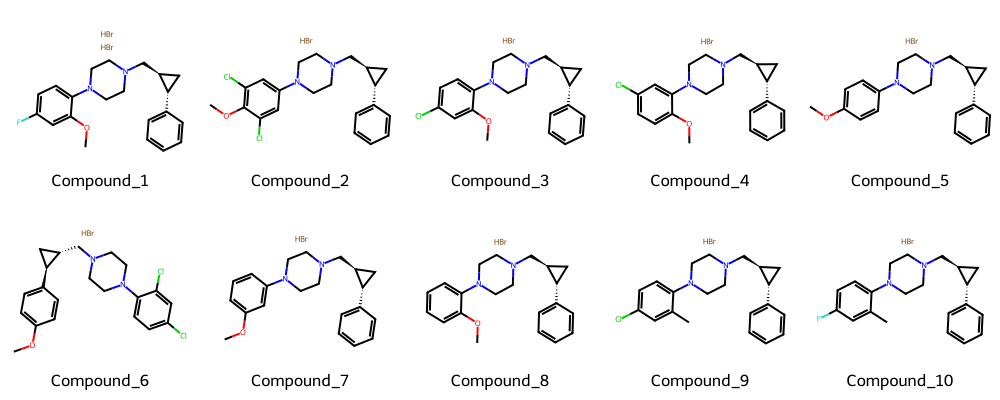

In [7]:
# Show only first 10 molecules -- use slicing
num_mols = 10
legends = [mol.GetProp("_Name") for mol in mols]
Draw.MolsToGridImage(mols[:num_mols], legends=legends[:num_mols], molsPerRow=5)

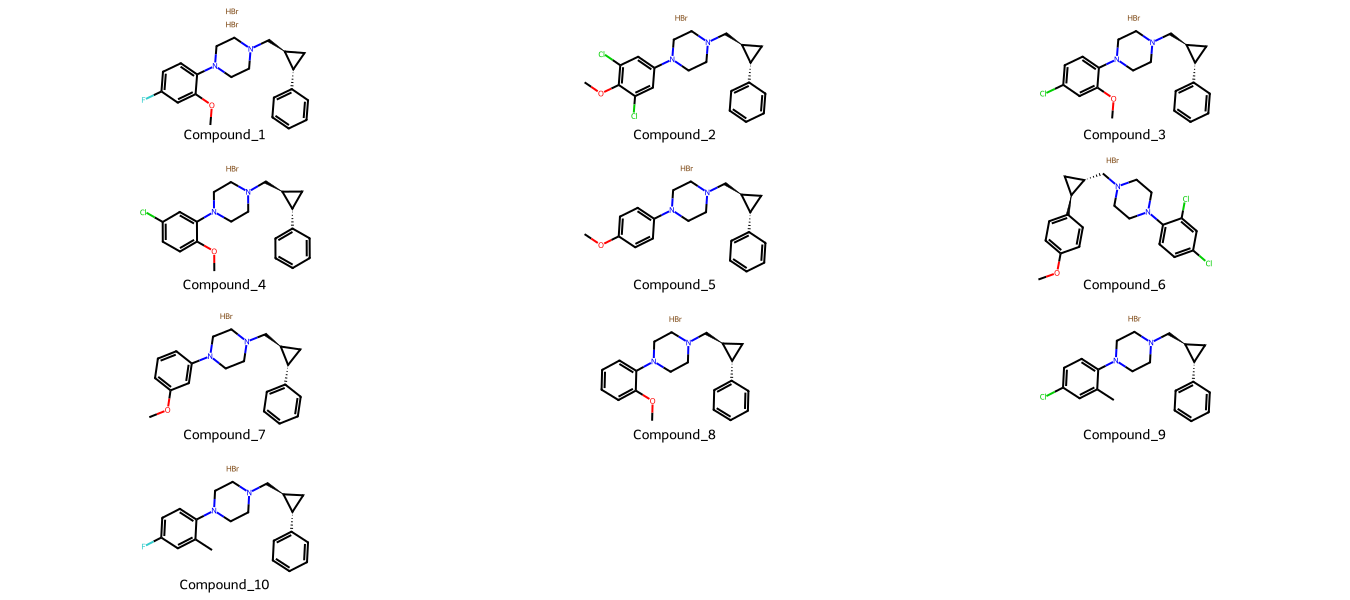

In [13]:
# Use the molecules and legends already created earlier in the notebook
img = Draw.MolsToGridImage(
    mols[:10],
    molsPerRow=3,
    subImgSize=(450, 150),
    legends=legends[:10],
)
img


In [24]:
molecules["maccs"] = molecules["smiles"].apply(
    lambda smiles: MACCSkeys.GenMACCSKeys(
        Chem.MolFromSmiles(smiles)
    )
)

In [27]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator()

molecules["morgan"] = molecules["smiles"].apply(lambda smiles: morgan_generator.GetFingerprint(Chem.MolFromSmiles(smiles)))

In [28]:
# Define molecule query and list
molecule_query = molecules["maccs"][0]
molecule_list = molecules["maccs"].to_list()
# Calculate similarty values between query and list elements
molecules["tanimoto_maccs"] = DataStructs.BulkTanimotoSimilarity(molecule_query, molecule_list)
molecules["dice_maccs"] = DataStructs.BulkDiceSimilarity(molecule_query, molecule_list)

In [32]:
preview = molecules.sort_values(["tanimoto_maccs"], ascending=False).reset_index()
preview[["smiles", "tanimoto_maccs", "dice_maccs"]]
# NBVAL_CHECK_OUTPUT

,smiles,tanimoto_maccs,dice_maccs
0,Br.Br.COc1cc(F)ccc1N1CCN(C[C@H]2C[C@@H]2c2cccc...,1.000000,1.000000
1,Br.COc1cc(Cl)ccc1N1CCN(C[C@H]2C[C@@H]2c2ccccc2...,0.942308,0.970297
2,Br.COc1ccc(Cl)cc1N1CCN(C[C@H]2C[C@@H]2c2ccccc2...,0.942308,0.970297
3,Br.COc1ccc([C@H]2C[C@@H]2CN2CCN(c3ccc(Cl)cc3Cl...,0.923077,0.960000
4,Br.COc1c(Cl)cc(N2CCN(C[C@H]3C[C@@H]3c3ccccc3)C...,0.923077,0.960000
...,...,...,...
470,CC/C(=C(/CC)c1ccc(O)cc1)c1ccc(O)cc1,0.254237,0.405405
471,CCN(CC)C(=S)SSC(=S)N(CC)CC,0.206349,0.342105
472,C=C1CCC[C@]2(C)Cc3occ(C)c3C[C@@H]12,0.194030,0.325000
473,NC(=O)C[S@@+]([O-])C(c1ccccc1)c1ccccc1,0.183099,0.309524


In [37]:
def draw_ranked_molecules(molecules, sort_by_column):
    molecules_sorted = (
        molecules.sort_values(sort_by_column, ascending=False)
        .reset_index(drop=True)
    )
    mols = [Chem.MolFromSmiles(smiles) for smiles in molecules_sorted["smiles"]]
    legends = [
        f"#{index + 1}, similarity={row[sort_by_column]:.2f}"
        for index, row in molecules_sorted.iterrows()
    ]

    return Draw.MolsToGridImage(
        mols,
        legends=legends,
        molsPerRow=3,
        subImgSize=(450, 150),
    )

C:\Users\ziyed\AppData\Roaming\Python\Python39\site-packages\rdkit\Chem\Draw\IPythonConsole.py:365: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


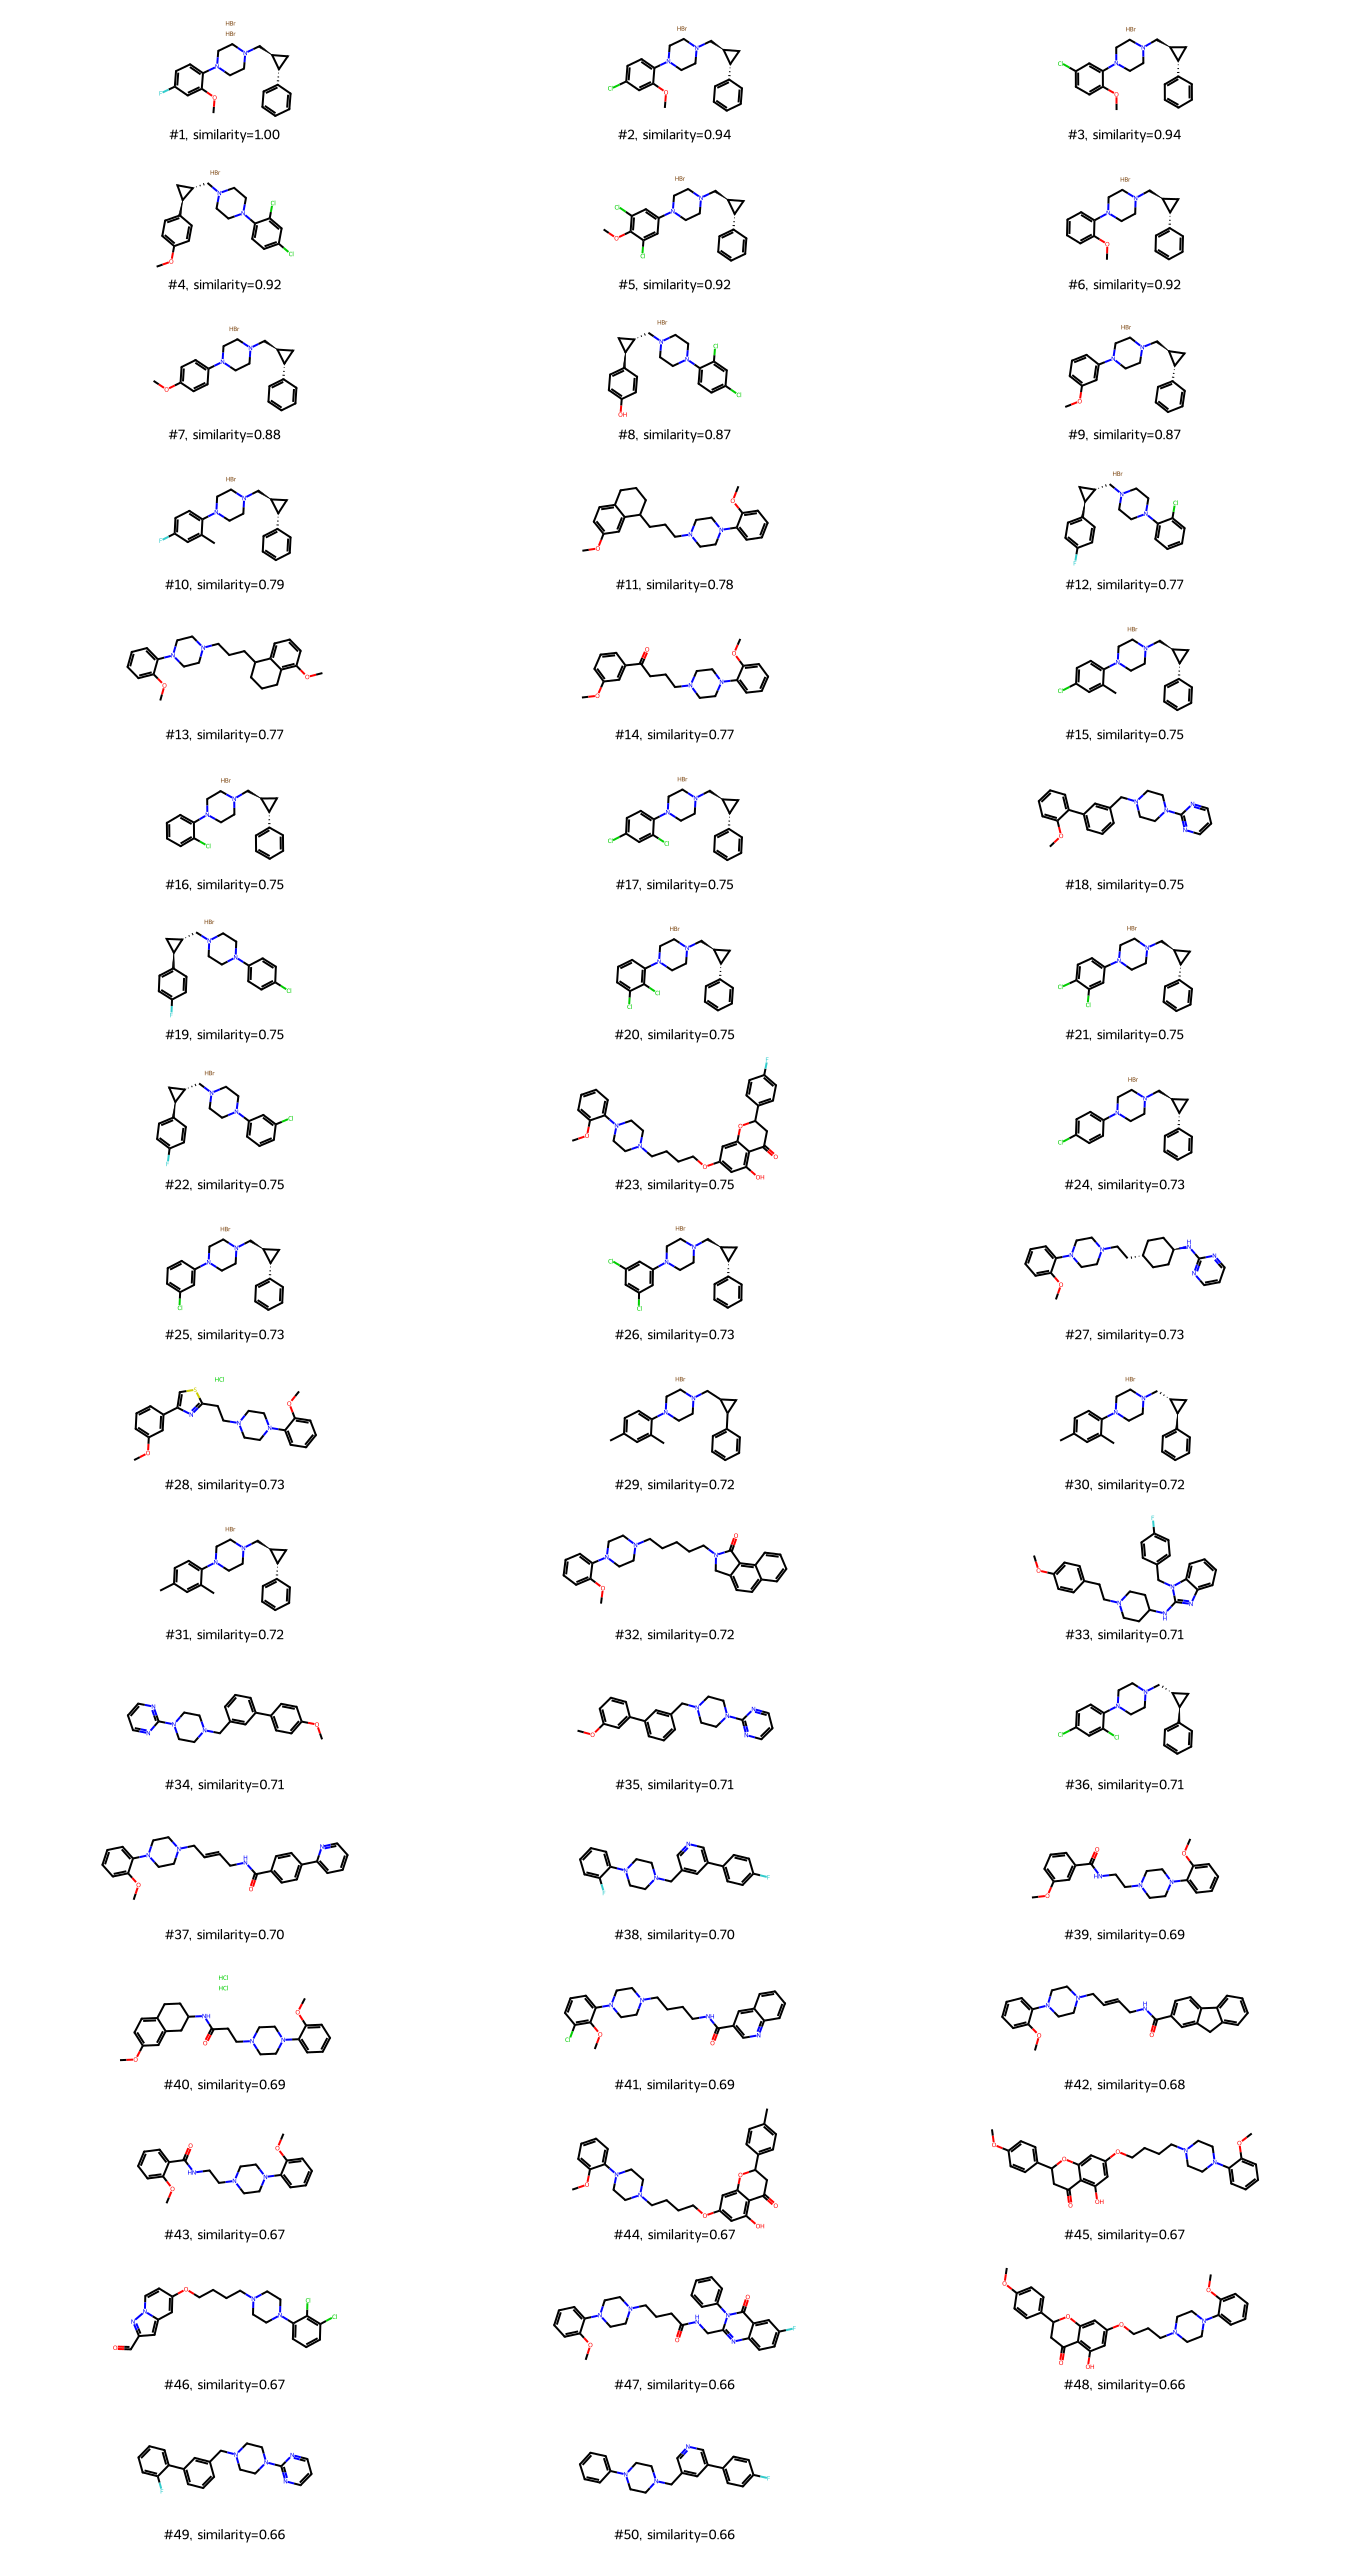

In [38]:
draw_ranked_molecules(molecules, "tanimoto_maccs")

In [39]:
# Define molecule query and list
molecule_query = molecules["morgan"][0]
molecule_list = molecules["morgan"].to_list()
# Calculate similarty values between query and list elements
molecules["tanimoto_morgan"] = DataStructs.BulkTanimotoSimilarity(molecule_query, molecule_list)
molecules["dice_morgan"] = DataStructs.BulkDiceSimilarity(molecule_query, molecule_list)

In [41]:
preview = molecules.sort_values(["tanimoto_morgan"], ascending=False).reset_index()
preview[["smiles", "tanimoto_morgan", "dice_morgan", "tanimoto_maccs", "dice_maccs"]]
# NBVAL_CHECK_OUTPUT

,smiles,tanimoto_morgan,dice_morgan,tanimoto_maccs,dice_maccs
0,Br.Br.COc1cc(F)ccc1N1CCN(C[C@H]2C[C@@H]2c2cccc...,1.000000,1.000000,1.000000,1.000000
1,Br.COc1cc(Cl)ccc1N1CCN(C[C@H]2C[C@@H]2c2ccccc2...,0.716216,0.834646,0.942308,0.970297
2,Br.COc1ccccc1N1CCN(C[C@H]2C[C@@H]2c2ccccc2)CC1,0.694444,0.819672,0.921569,0.959184
3,Br.Cc1cc(F)ccc1N1CCN(C[C@H]2C[C@@H]2c2ccccc2)CC1,0.675676,0.806452,0.788462,0.881720
4,Br.COc1ccc(Cl)cc1N1CCN(C[C@H]2C[C@@H]2c2ccccc2...,0.615385,0.761905,0.942308,0.970297
...,...,...,...,...,...
470,CN(C)c1ccc(C(=C2C=CC(=[N+](C)C)C=C2)c2ccc(N(C)...,0.052083,0.099010,0.311475,0.475000
471,CCN(CC)C(=S)SSC(=S)N(CC)CC,0.050633,0.096386,0.206349,0.342105
472,CCCCCNC(=O)/N=C(\N)NCCCc1nnc(N)s1.O=C(O)C(F)(F...,0.049587,0.094488,0.307692,0.470588
473,CCCCCCNC(=O)/N=C(\N)NCCCc1nnc(N)s1.O=C(O)C(F)(...,0.049180,0.093750,0.318681,0.483333


C:\Users\ziyed\AppData\Roaming\Python\Python39\site-packages\rdkit\Chem\Draw\IPythonConsole.py:365: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


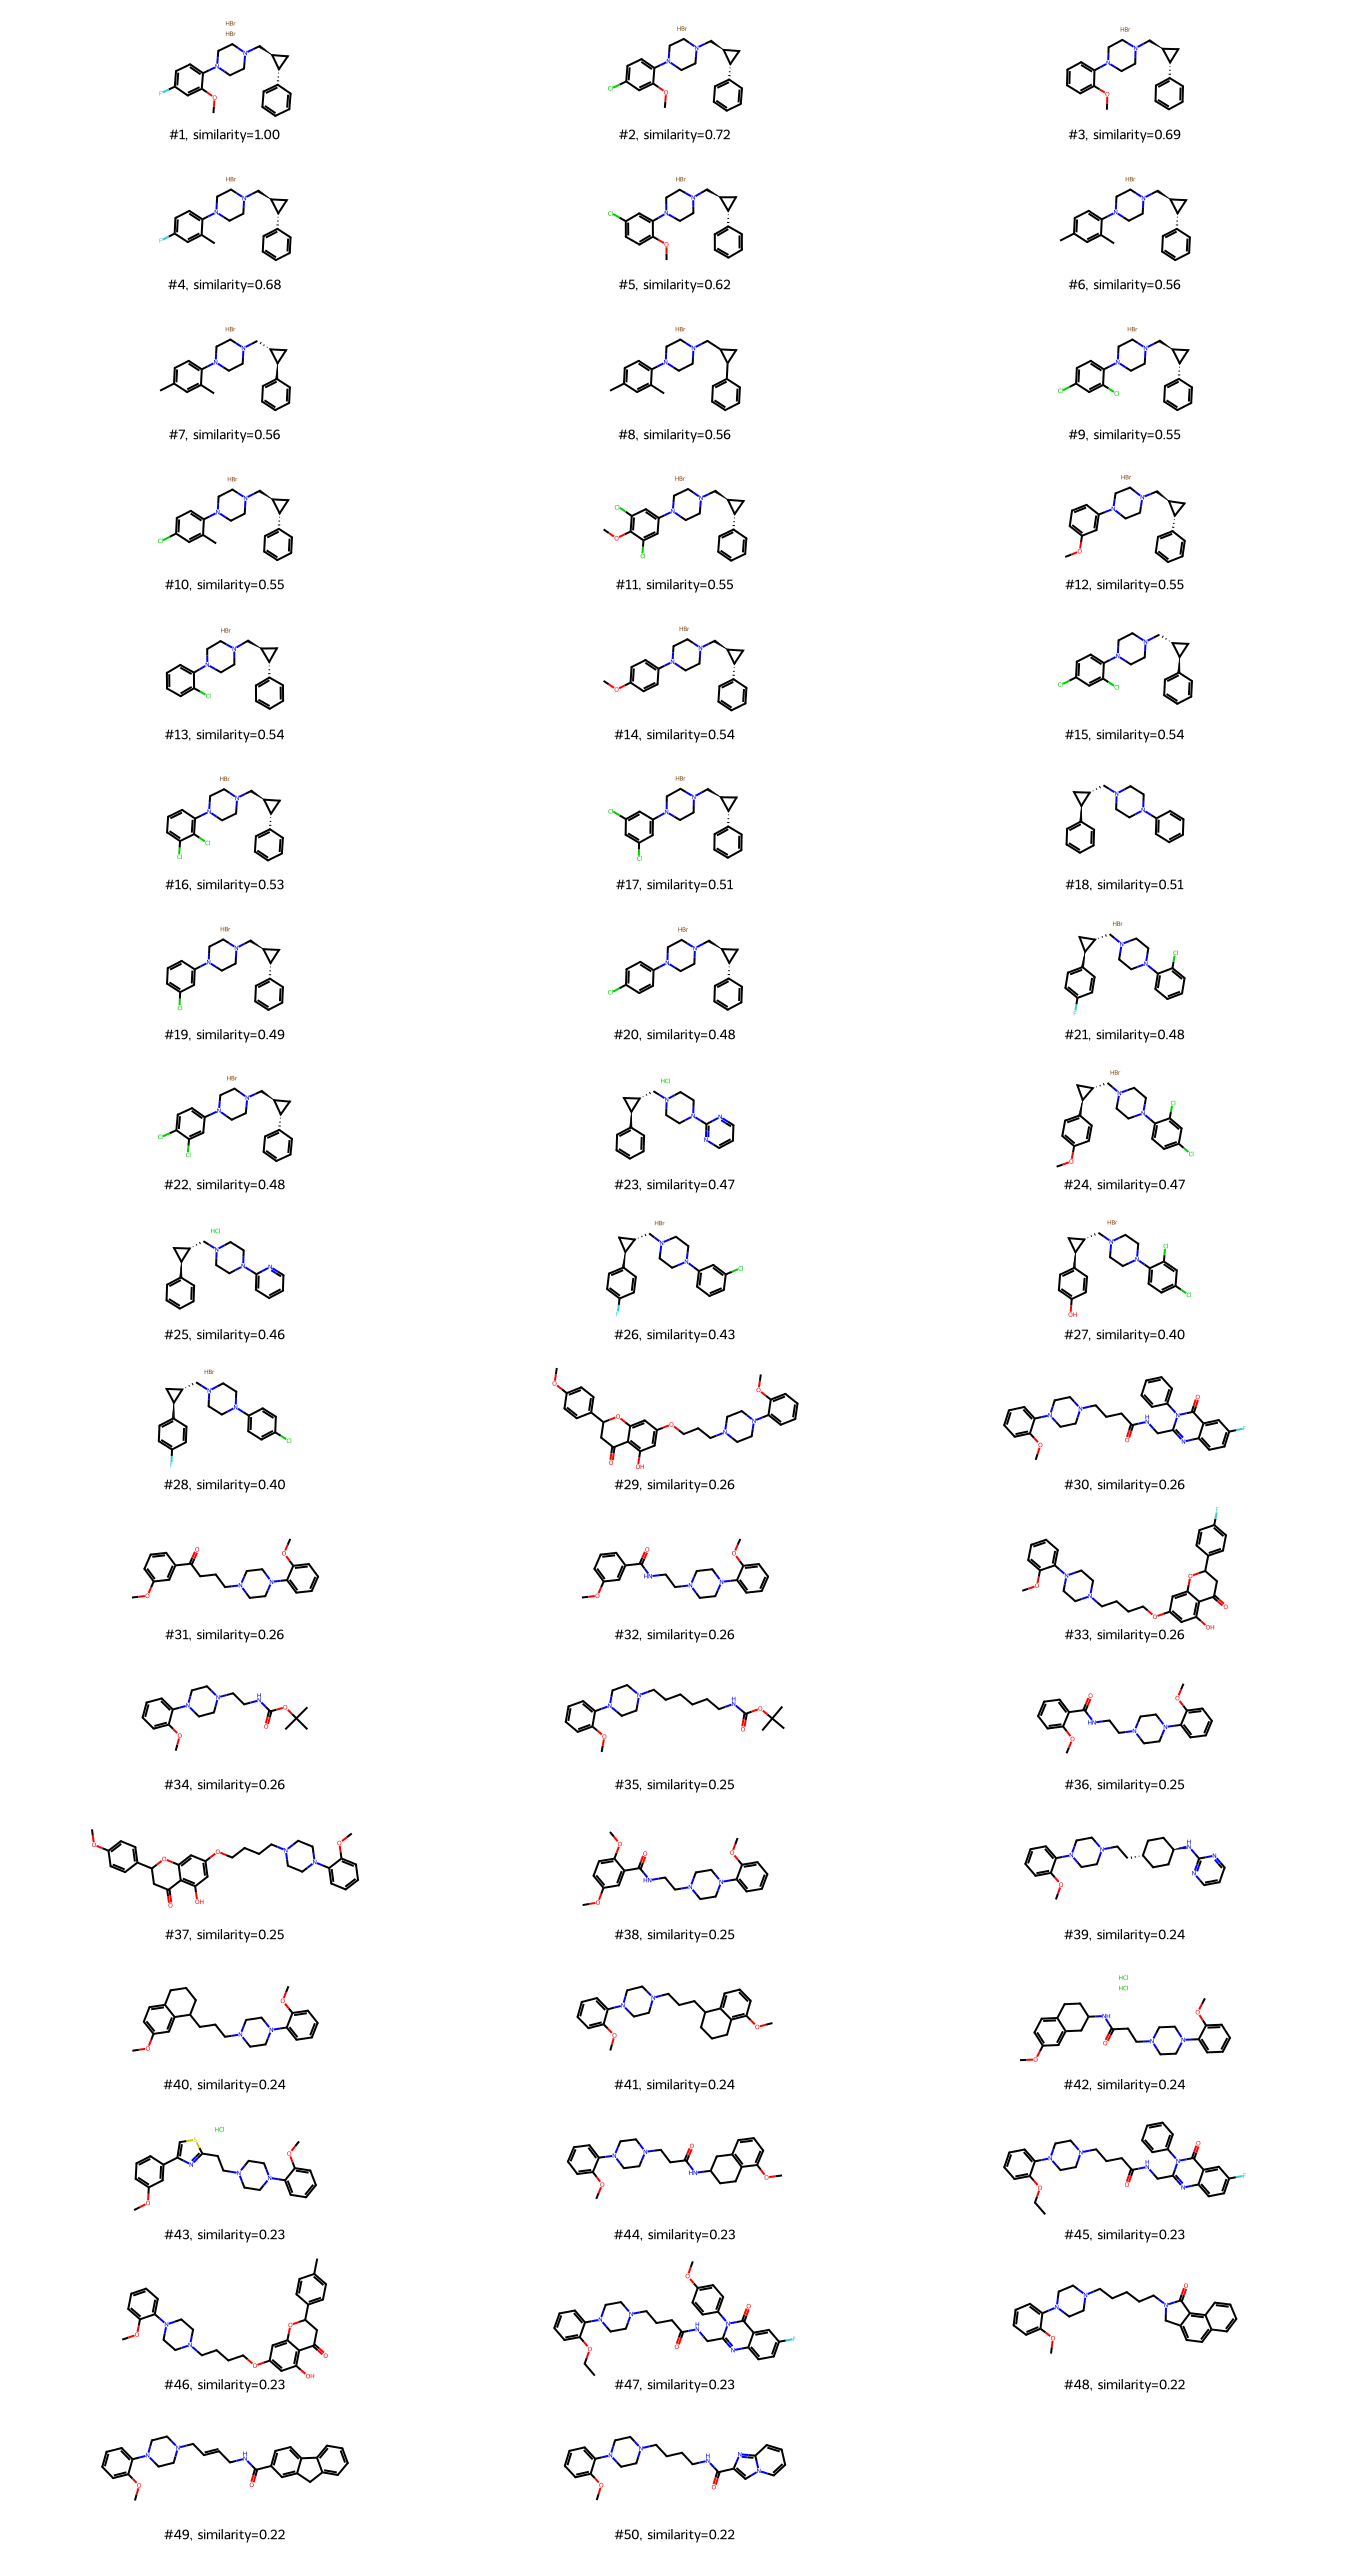

In [42]:
draw_ranked_molecules(molecules, "tanimoto_morgan")

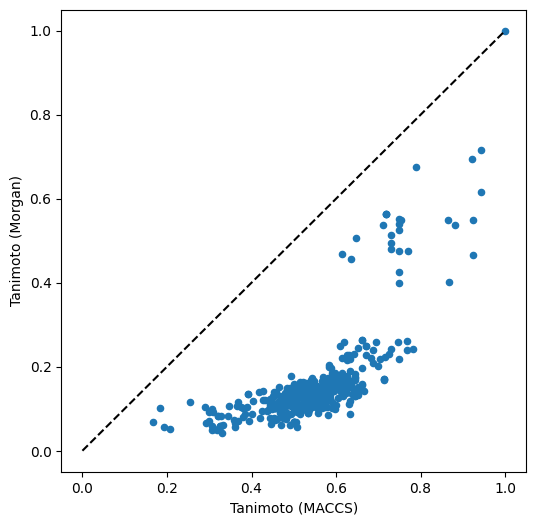

In [43]:
fig, ax = plt.subplots(figsize=(6, 6))
molecules.plot("tanimoto_maccs", "tanimoto_morgan", kind="scatter", ax=ax)
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("Tanimoto (MACCS)")
ax.set_ylabel("Tanimoto (Morgan)")
fig;